## Common solution - seperation of variables
$$ \frac{dy}{dx} = xy^2 + x $$
$$ \frac{dy}{dx} = x(y^2 + 1) $$
$$ \frac{1}{y^2 + 1}dy = xdx $$
$$ \int\frac{1}{y^2 + 1}dy = \int xdx $$
$$ \arctan(y) + C_2 = \frac{x^2}{2} + C_1 $$
$$ y = f(x) = \tan{(\frac{x^2}{2} + C)} $$
Given $f(-1) = 1$:
$$ \tan{(\frac{(-1)^2}{2}+C)} = 1 $$
$$ \frac{1}{2} + C = \frac{\pi}{4} $$
$$ C = \frac{\pi - 2}{4} $$
So the full solution is:
$$ f(x) = \tan{(\frac{x^2}{2} + \frac{\pi - 2}{4})} $$
$$ y = f(x) = \tan{(\frac{2x^2 + \pi - 2}{4})} $$

## Numerical solution - Symmetrical Euler method (Trapezoid rule)
$$
y' = f(x, y) = x y^2 + x
$$

$$
U^{n+1} = U^n + \frac{\tau}{2} \left( f(t_n, U^n) + f(t_{n+1}, U^{n+1}) \right)
$$

$$
U^{n+1} = U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} (U^{n+1})^2 + t_{n+1} \right)
$$

$$
U^{n+1} - \frac{\tau}{2} t_{n+1} (U^{n+1})^2 = U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right)
$$

$$
U^{n+1} - \frac{\tau}{2} t_{n+1} (U^{n+1})^2 = U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right)
$$

$$
u(x) = x - \frac{\tau}{2} t_{n+1} (x)^2 - \left( U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right) \right) = 0
$$

Solving for $x$ using non-linear equation methods will yield $U^{n+1}$. Here: start value - $U^{(0)}$, steps in the domain - $t_n$, the step size - $\tau$, are known:
$$
u(x) = 0, x = U^{n+1}
$$

Using simple iterations, finding $g(x) = x$:
$$
u(x) = 0 \rightarrow x - \frac{\tau}{2} t_{n+1} (x)^2 - \left( U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right) \right) = 0
$$

$$
g(x) = x = \frac{\tau}{2} t_{n+1} (x)^2 + \left( U^n + \frac{\tau}{2} \left( t_n (U^n)^2 + t_n + t_{n+1} \right) \right)
$$

So that iteration $x_{i+1} = g(x_i)$ reaches $g(x_i) = x_i + \epsilon$ with some error $\epsilon$ when $|g(x_i) - x_i| \leq \frac{1-q}{q}\epsilon$, where $q = |g'(x_i)| = |\tau x_i t_{n+1}| < 1$ \
And because $max(|\tau x_i t_{n+1}|) \rightarrow +\infty < 1$ is not true, the process converges
.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
class SimpleIterationsSolver:
  def setup(self, g, g_, x0, min_error=1e-5):
    self.g = g
    self.g_ = g_
    self.x0 = x0
    self.min_error = min_error
    return self

  def _f_error(self, x):
    return abs(self.g(x) - x)

  def _f_min_error_bound(self, x):
    return (1 - self.g_(x)) / self.g_(x) * self.min_error

  def _min_error_reached(self, x_i, error):
    return error <= self._f_min_error_bound(x_i, self.min_error)

  def solve(self):
    i = 0
    x_i = self.x0
    min_error_bound = self._f_min_error_bound(x_i)
    error = self._f_error(x_i)
    while not self._min_error_reached(x_i, error):
      x_i = self.g(x_i)
      min_error_bound = self._f_min_error_bound(x_i)
      error = self._f_error(x_i)
      i += 1
    return x_i

In [24]:
from scipy.optimize import fsolve
import warnings

class IterationsSolver:
  def setup(self, f, x0):
    self.f = f
    self.x0 = x0
    return self
  
  def solve(self):
    with warnings.catch_warnings():
      warnings.simplefilter("ignore", category=RuntimeWarning)
      roots = fsolve(self.f, self.x0)
    if len(roots) > 1:
      print(f'Multiple roots found {roots}')
      raise ValueError
    return roots[0]

In [11]:
def display_dataframe_with_title(title, data):
  from IPython.display import display, Markdown
  display(Markdown(f"### {title}"))
  display(data)

In [25]:
# Third-Order Runge-Kutta and Symmetric Euler solutions
def solve_ode(step):
  x_interval = [-1, 28]
  n = int((x_interval[1] - x_interval[0]) / step)
  ts = np.linspace(x_interval[0], x_interval[1], n)
  Us_runge = np.zeros(n)
  Us_runge[0] = 1
  Us_euler = np.zeros(n)
  Us_euler[0] = Us_runge[0]
  a = [0.5, 1]
  b = [0.5, -1, 2]
  sig = [1/6, 2/3, 1/6]
  f = lambda x, y: x*y*y + x
  # the real solution to y
  g = lambda x: np.tan((2*x*x + np.pi - 2)/4)
  # L1 norm
  f_error = lambda x, y: abs(x - y)
  Us_real = g(ts)
  full_error_runge = 0
  full_error_euler = 0
  df = pd.DataFrame(columns=['iter.i', 't_i', 'U(i+1)_runge', 'U(i+1)_euler',
  'U(i+1)_real', 'L1_error_runge', 'L1_error_euler', 'error_average_runge', 'error_average_euler'])
  for i in range(n-1):
    k1 = f(ts[i], Us_runge[i])
    k2 = f(ts[i] + a[0] * step, Us_runge[i] + b[0] * step * k1)
    k3 = f(ts[i] + a[1] * step, Us_runge[i] + step * (b[1] * k1 + b[2] * k2))
    Us_runge[i+1] = Us_runge[i] + step * (sig[0] * k1 + sig[1] * k2 + sig[2] * k3)
    full_error_runge += f_error(Us_real[i+1], Us_runge[i+1])
    # Us_euler[i+1] = SimpleIterationsSolver()\
    # .setup(
    #   lambda x: x - step/2 * ts[i+1] * x*x - (Us_euler[i] + step/2 * (ts[i] * Us_euler[i] * Us_euler[i] + ts[i] + ts[i+1])),
    #   lambda x: step * x * ts[i+1],
    #   x0=0
    # ).solve()
    Us_euler[i+1] = IterationsSolver()\
    .setup(
      lambda x: x - step/2 * ts[i+1] * x*x - (Us_euler[i] + step/2 * (ts[i] * Us_euler[i] * Us_euler[i] + ts[i] + ts[i+1])),
      x0=0
    ).solve()
    full_error_euler += f_error(Us_real[i+1], Us_euler[i+1])
    df.loc[i] = [i, ts[i], Us_runge[i+1], Us_euler[i+1], Us_real[i+1],
                 f_error(Us_real[i+1], Us_runge[i+1]), f_error(Us_real[i+1],
                  Us_euler[i+1]), full_error_runge/(i+1), full_error_euler/(i+1)]

  plt.figure()
  plt.plot(ts, Us_real, 'o', label='Real values')
  plt.plot(ts, Us_runge, 'o', label='Runge-Kutta 3rd order')
  plt.plot(ts, Us_euler, 'o', label='Euler\'s symmetric')
  plt.title(f'y\' = x*y*y + x, y approximation and real values, step = {step}')
  plt.legend()
  plt.xlabel('x')
  plt.ylabel('y')
  plt.ylim(-20, 20)
  plt.plot()
  display_dataframe_with_title(f'Iteration table, step: {step}', df)
  return (df["error_average_runge"].iloc[-1], df["error_average_euler"].iloc[-1])

C:\Users\Jogmi\AppData\Local\Temp\ipykernel_17596\2261925517.py:13: RuntimeWarning: overflow encountered in scalar multiply
  f = lambda x, y: x*y*y + x
C:\Users\Jogmi\AppData\Local\Temp\ipykernel_17596\2261925517.py:26: RuntimeWarning: invalid value encountered in scalar add
  k3 = f(ts[i] + a[1] * step, Us_runge[i] + step * (b[1] * k1 + b[2] * k2))


### Iteration table, step: 0.5

,iter.i,t_i,U(i+1)_runge,U(i+1)_euler,U(i+1)_real,L1_error_runge,L1_error_euler,error_average_runge,error_average_euler
0,0.0,-1.000000,4.321289e-01,0.361173,0.429944,2.185053e-03,0.068771,2.185053e-03,0.068771
1,1.0,-0.491228,2.974321e-01,0.226958,0.293575,3.856929e-03,0.066617,3.020991e-03,0.067694
2,2.0,0.017544,4.539797e-01,0.382389,0.451261,2.718436e-03,0.068872,2.920139e-03,0.068087
3,3.0,0.526316,1.072357e+00,1.111911,1.074083,1.726123e-03,0.037828,2.621635e-03,0.060522
4,4.0,1.035088,5.720805e+00,1.295835,10.647181,4.926376e+00,9.351347,9.873725e-01,1.918687
5,5.0,1.543860,6.388006e+04,0.974527,-0.930749,6.388099e+04,1.905276,1.064765e+04,1.916452
6,6.0,2.052632,2.168879e+37,0.781550,0.451619,2.168879e+37,0.329931,3.098398e+36,1.689806
7,7.0,2.561404,1.660122e+298,0.650186,-3.400674,1.660122e+298,4.050860,2.075153e+297,1.984938
8,8.0,3.070175,NaN,0.558805,0.430648,NaN,0.128156,NaN,1.778629
9,9.0,3.578947,NaN,0.489634,-0.998515,NaN,1.488149,NaN,1.749581


C:\Users\Jogmi\AppData\Local\Temp\ipykernel_17596\2261925517.py:13: RuntimeWarning: overflow encountered in scalar multiply
  f = lambda x, y: x*y*y + x
C:\Users\Jogmi\AppData\Local\Temp\ipykernel_17596\2261925517.py:26: RuntimeWarning: invalid value encountered in scalar add
  k3 = f(ts[i] + a[1] * step, Us_runge[i] + step * (b[1] * k1 + b[2] * k2))


### Iteration table, step: 0.25

...

### Iteration table, step: 0.0625

,iter.i,t_i,U(i+1)_runge,U(i+1)_euler,U(i+1)_real,L1_error_runge,L1_error_euler,error_average_runge,error_average_euler
0,0.0,-1.000000,0.885694,0.885252,0.885462,0.000232,0.000210,0.000232,0.000210
1,1.0,-0.937365,0.789370,0.788665,0.788963,0.000408,0.000297,0.000320,0.000254
2,2.0,-0.874730,0.707154,0.706290,0.706608,0.000545,0.000318,0.000395,0.000275
3,3.0,-0.812095,0.636337,0.635377,0.635681,0.000656,0.000304,0.000460,0.000283
4,4.0,-0.749460,0.574987,0.573967,0.574239,0.000747,0.000272,0.000518,0.000281
...,...,...,...,...,...,...,...,...,...
458,458.0,27.686825,NaN,0.577846,-2.035925,NaN,2.613771,NaN,9.349693
459,459.0,27.749460,NaN,0.575915,0.722727,NaN,0.146812,NaN,9.329687
460,460.0,27.812095,NaN,0.573528,-0.973175,NaN,1.546702,NaN,9.312804
461,461.0,27.874730,NaN,0.572526,1.478433,NaN,0.905906,NaN,9.294607


C:\Users\Jogmi\AppData\Local\Temp\ipykernel_17596\2261925517.py:13: RuntimeWarning: overflow encountered in scalar multiply
  f = lambda x, y: x*y*y + x
C:\Users\Jogmi\AppData\Local\Temp\ipykernel_17596\2261925517.py:26: RuntimeWarning: invalid value encountered in scalar add
  k3 = f(ts[i] + a[1] * step, Us_runge[i] + step * (b[1] * k1 + b[2] * k2))


### Iteration table, step: 0.03125

,iter.i,t_i,U(i+1)_runge,U(i+1)_euler,U(i+1)_real,L1_error_runge,L1_error_euler,error_average_runge,error_average_euler
0,0.0,-1.000000,0.940295,0.940233,0.940233,0.000062,5.327543e-09,0.000062,5.327543e-09
1,1.0,-0.968716,0.885690,0.885581,0.885575,0.000115,6.037595e-06,0.000089,3.021461e-06
2,2.0,-0.937433,0.835552,0.835406,0.835390,0.000162,1.609301e-05,0.000113,7.378645e-06
3,3.0,-0.906149,0.789357,0.789183,0.789154,0.000203,2.876081e-05,0.000136,1.272419e-05
4,4.0,-0.874865,0.746670,0.746474,0.746431,0.000239,4.307037e-05,0.000156,1.879342e-05
...,...,...,...,...,...,...,...,...,...
922,922.0,27.843581,NaN,1.147005,-0.965867,NaN,2.112872e+00,NaN,6.301913e+00
923,923.0,27.874865,NaN,1.147743,0.104863,NaN,1.042879e+00,NaN,6.296222e+00
924,924.0,27.906149,NaN,1.145313,1.484463,NaN,3.391502e-01,NaN,6.289781e+00
925,925.0,27.937433,NaN,1.143883,-3.456016,NaN,4.599899e+00,NaN,6.287957e+00


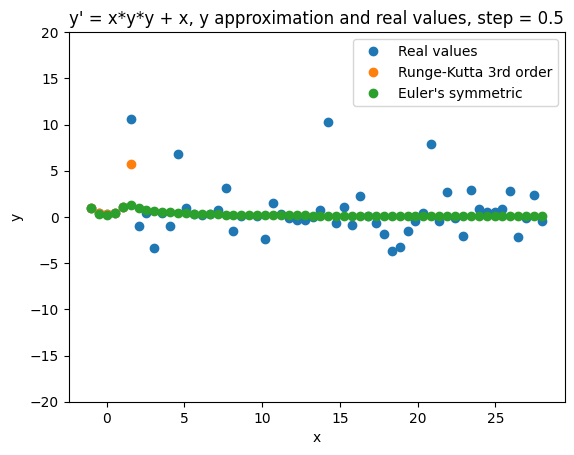

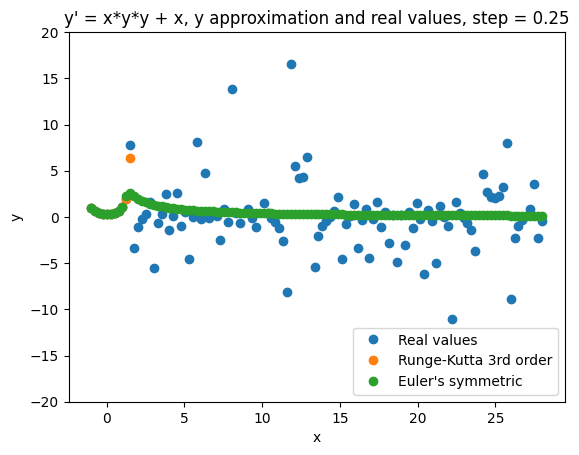

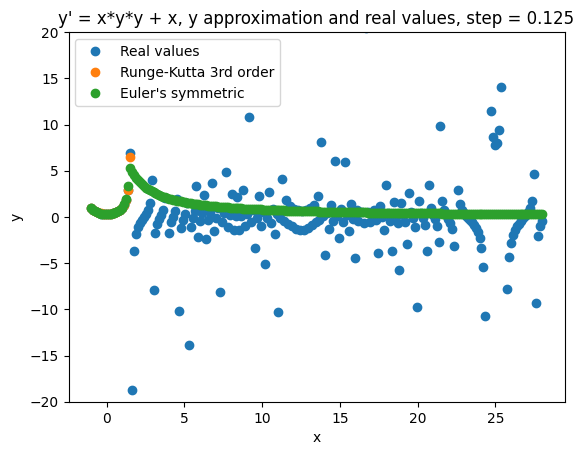

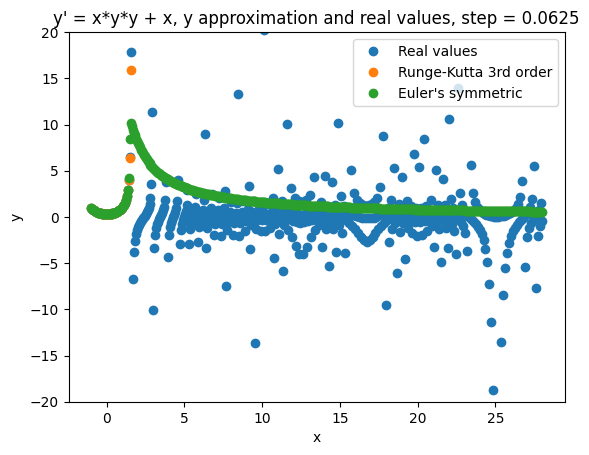

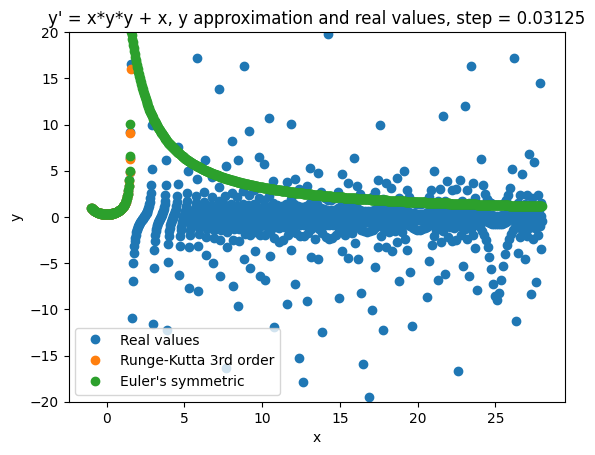

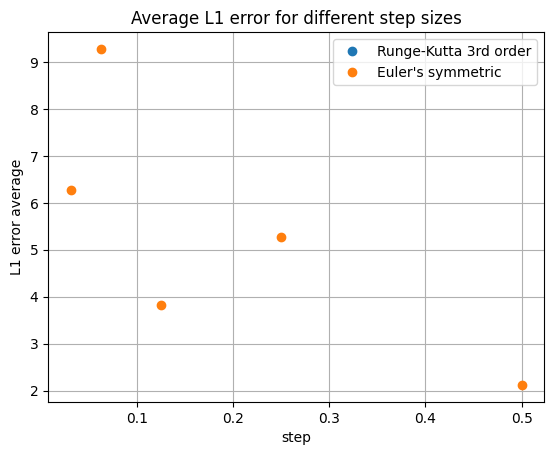

In [30]:
steps = [0.5, 0.25, 0.125, 0.0625, 0.03125]
error_average_eulers = []
error_average_runges = []
for step in steps:
  error_average_runge, error_average_euler = solve_ode(step)
  error_average_eulers.append(error_average_euler)
  error_average_runges.append(error_average_runge)

plt.figure()
plt.plot(steps, error_average_runges, 'o', label='Runge-Kutta 3rd order')
plt.plot(steps, error_average_eulers, 'o', label='Euler\'s symmetric')
plt.title('Average L1 error for different step sizes')
plt.xlabel('step')
plt.ylabel('L1 error average')
plt.legend()
plt.grid()
plt.show()